In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [3]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
      AND rtParent.title != 'No Gesture'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [4]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [5]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [6]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
Tap and Hold                      47996
Pinch Swipe                       40992
Two-Finger Double Tap             33695
Two-Finger Tap                    32830
Double Tap                        29174
Spread Swipe                      27860
Two-Finger Opposite Double Tap    26502
Single Swipe                      26145
Two-Finger Opposite Tap           25104
Single Tap                        23568
Name: count, dtype: int64

In [7]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [8]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    38482
6331fbd1-76bb-48d6-92a2-80a55a70d134    28910
696b4743-9d39-4fb1-8271-90e7d48652af    20781
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    51178
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    40655
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    38518
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    45339
fdd02af8-c764-43ba-8247-c612f85568b4    50003
dtype: int64

In [9]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [10]:
# Drop rows where touch_1_position is null
initial_row_count = len(df_raw)
df_raw = df_raw.dropna(subset=['touch_1_position']).reset_index(drop=True)
dropped_row_count = initial_row_count - len(df_raw)
print(f"Dropped {dropped_row_count} rows with null touch_1_position.")

Dropped 79425 rows with null touch_1_position.


In [11]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [12]:
# Stabilize dataframe
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Stabilization Complete.


In [13]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(2, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position     58108
touch_1_pressure     58108
touch_1_channel      58108
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            183923
dtype: int64

In [14]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")

Min samples per group_id: 7
Max samples per group_id: 406
Mean samples per group_id: 50.62
Parent gesture for group_id with max samples (07833f80-61a1-454f-a06b-142a3c96b461): Tap and Hold
Parent gesture for group_id with min samples (22ef7b18-9168-4632-bbe8-2a065e710fce): Two-Finger Opposite Tap
Max samples for 'No Gesture' group_id: nan


In [15]:
# Change the WINDOW_GESTURE_MAJORITY_THRESHOLD based on the minimum samples per group_id, so that a window, that only includes the minimum amount of samples can still be labeled
WINDOW_GESTURE_MAJORITY_THRESHOLD = 1 / grouped.min()

In [16]:
# Create sliding windows from the cleaned DataFrame
X_windows = []
y_windows = []
meta_data = []
print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values
    is_gesture = group['is_gesture'].values
    
    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE_SAMPLES + 1, WINDOW_STRIDE_SAMPLES):
        end = start + WINDOW_SIZE_SAMPLES
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]
        window_is_gesture = is_gesture[start:end]
        
        # Majority label in the window, where as long as WINDOW_GESTURE_MAJORITY_THRESHOLD of the labels are the same and not 'No Gesture', that label is assigned
        label_counts = pd.Series(window_labels).value_counts(normalize=True)
        majority_label = 'No Gesture'
        for label, proportion in label_counts.items():
            if label != 'No Gesture' and proportion >= WINDOW_GESTURE_MAJORITY_THRESHOLD:
                majority_label = label
                break
        # Same goes for is_gesture, only if less than WINDOW_GESTURE_MAJORITY_THRESHOLD of the samples are gestures, label as no gesture
        is_gesture_counts = pd.Series(window_is_gesture).value_counts(normalize=True)
        if is_gesture_counts.get(1, 0) < WINDOW_GESTURE_MAJORITY_THRESHOLD:
            majority_label = 'No Gesture'
        
        X_windows.append(window_data)
        y_windows.append(majority_label)
        meta_data.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end
        })
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_data_df = pd.DataFrame(meta_data)
print(f"Created {X_windows.shape[0]} windows of size {WINDOW_SIZE_SAMPLES} samples.")
# Display the shape of the created windows
X_windows.shape, y_windows.shape, meta_data_df.shape


Creating sliding windows...
Created 11320 windows of size 60 samples.


((11320, 60, 17), (11320,), (11320, 4))

In [17]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
Double Tap: 344
No Gesture: 7431
Pinch Swipe: 580
Single Swipe: 383
Single Tap: 283
Spread Swipe: 425
Tap and Hold: 807
Two-Finger Double Tap: 365
Two-Finger Opposite Double Tap: 224
Two-Finger Opposite Tap: 161
Two-Finger Tap: 317


In [18]:
def extract_features(window, is_padded_window):
    features = []
    feature_names = [] # for debug purposes we store the names of each feature at the same index
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]  # touch_X_channel indices
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    original_length_col = len(SENSOR_COLUMNS)  # last column is original length

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]
    # Only consider touch positions where the pressure > 0
    valid_mask = touch_pressures > 0
    touch_positions = touch_positions[valid_mask]
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)
    
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    add_feature("any_touch", np.any(active_touches))
    # 4. Total pressure across all sensors
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    # 5. Max pressure
    add_feature("max_pressure", np.max(touch_pressures))
    # 5.1 Min non-zero pressure
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    add_feature("touch_centroid", touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    add_feature("touch_spread", 1 - touch_position_R)
    add_feature("touch_spread_log", -np.log(np.clip(touch_position_R, 1e-9, 1.0)))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    i = 0
    for p1, p2 in combinations(touch_position_cols, 2):
        i += 1
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]
        # Only consider positions where the pressure > 0
        finger1_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p1)]]
        finger2_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p2)]]
        valid_mask = (finger1_pressures > 0) & (finger2_pressures > 0)
        finger1_positions = finger1_positions[valid_mask]
        finger2_positions = finger2_positions[valid_mask]

        distances = short_dist(finger1_positions, finger2_positions)

        # Calculate the distances for the first and last third of the window
        third_length = len(distances) // 3
        first_third_distances = distances[:third_length]
        last_third_distances = distances[-third_length:]
        add_feature("finger_distance_mean_first_third_" + str(i), np.mean(first_third_distances) if len(first_third_distances) > 0 else 0)
        add_feature("finger_distance_mean_last_third_" + str(i), np.mean(last_third_distances) if len(last_third_distances) > 0 else 0)

        # If the distances are empty add 0 for all
        has_distance = len(distances) != 0
        add_feature("finger_distance_mean_" + str(i), np.mean(distances) if has_distance else 0)
        add_feature("finger_distance_std_" + str(i), np.std(distances) if has_distance else 0)
        add_feature("finger_distance_max_" + str(i), np.max(distances) if has_distance else 0)
        add_feature("finger_distance_min_" + str(i), np.min(distances) if has_distance else 0)
        # add_feature("finger_distance_range_" + str(i), circular_range(distances) if has_distance else 0)
        add_feature("finger_distance_q25_" + str(i), np.percentile(distances, 25) if has_distance else 0)
        add_feature("finger_distance_q75_" + str(i), np.percentile(distances, 75) if has_distance else 0)


    amount_active_moving_fingers = 0
    # Per Finger Features
    for i, (pos_col, press_col, channel_col) in enumerate(zip(touch_position_cols, touch_pressure_cols, touch_channel_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]
        finger_channels = window[:, channel_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # Only consider positions where the pressure > 0
        valid_mask = finger_pressures > 0
        finger_positions = finger_positions[valid_mask]
        finger_channels = finger_channels[valid_mask]

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Get the time between reactivations
        touch_reactivation_times = []
        last_touch_end = None
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                if last_touch_end is not None:
                    touch_reactivation_times.append(t - last_touch_end)
            if not is_touching[t] and is_touching[t - 1]:
                last_touch_end = t
        # Mean time between reactivations
        add_feature(f"finger_{i+1}_mean_time_between_reactivations", np.mean(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Std Dev time between reactivations
        add_feature(f"finger_{i+1}_std_time_between_reactivations", np.std(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Max time between reactivations
        add_feature(f"finger_{i+1}_max_time_between_reactivations", np.max(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Min time between reactivations
        add_feature(f"finger_{i+1}_min_time_between_reactivations", np.min(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Range time between reactivations
        # add_feature(f"finger_{i+1}_range_time_between_reactivations", np.abs(np.max(touch_reactivation_times) - np.min(touch_reactivation_times)) if len(touch_reactivation_times) > 0 else 0)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        # add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        # add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)
            # 8. Skewness / Kurtosis
            add_feature(f"finger_{i+1}_{data_type}_skewness", stats.skew(data) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_kurtosis", stats.kurtosis(data) if has_data else 0)
            if data_type == "channels":
                continue
            # 9. Velocity
            has_velocity = len(data) > 1
            pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
            add_feature(f"finger_{i+1}_{data_type}_velocity_mean", np.mean(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_std", np.std(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_max", np.max(pressure_velocity) if has_velocity else 0)
            if data_type == "pressures":
                continue
            # 10. Acceleration
            has_acceleration = len(data) > 2
            pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_mean", np.mean(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_std", np.std(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_max", np.max(pressure_acceleration) if has_acceleration else 0)

    # 8. Amount of fingers minus the amount of fingers that are constantly touching and not moving
    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [19]:
le = LabelEncoder()
y_windows_encoded = le.fit_transform(y_windows)

In [20]:
# Print nan for both datasets before feature extraction
print(f"NaN in windows before feature extraction: {np.isnan(X_windows).any()}")

NaN in windows before feature extraction: True


In [21]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_windows_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_windows_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (11320, 371)


In [22]:
# Print nan for both datasets after feature extraction
print(f"NaN in windows after feature extraction: {np.isnan(X_windows_extracted).any()}")

NaN in windows after feature extraction: True


In [23]:
# Set all nan values to 0
X_win = np.nan_to_num(X_windows_extracted, nan=0.0)

In [24]:
# Lets visualize the X_sequences for the "Double Tap" gesture
gesture_name = "Single Tap"
print("Values for gesture:", gesture_name)
gesture_index = np.where(le.classes_ == gesture_name)[0][0]
indices = np.where(y_windows_encoded == gesture_index)[0]
if len(indices) == 0:
    print(f"No samples found for gesture: {gesture_name}")
else:
    sample_index = indices[0]
    sample_features = X_win[sample_index]

    # Print the values with the feature name for this row
    for fname, fvalue in zip(feature_names, sample_features):
        print(f"{fname}: {fvalue}")

Values for gesture: Single Tap
max_simultaneous_touches: 4.0
avg_active_touches: 3.433333396911621
any_touch: 1.0
total_active_touch_samples: 206.0
total_pressure: 173240.0
max_pressure: 1304.0
min_non_zero_pressure: 400.0
touch_centroid: 4.101728439331055
touch_spread: 0.653839111328125
touch_spread_log: 1.0608515739440918
finger_distance_mean_first_third_1: 2.0551090240478516
finger_distance_mean_last_third_1: 2.044313907623291
finger_distance_mean_1: 2.0530710220336914
finger_distance_std_1: 0.008698796853423119
finger_distance_max_1: 2.059629440307617
finger_distance_min_1: 2.0298173427581787
finger_distance_q25_1: 2.0546929836273193
finger_distance_q75_1: 2.0583386421203613
finger_distance_mean_first_third_2: 2.8318819999694824
finger_distance_mean_last_third_2: 2.8371715545654297
finger_distance_mean_2: 2.8330633640289307
finger_distance_std_2: 0.004820851609110832
finger_distance_max_2: 2.8440299034118652
finger_distance_min_2: 2.823122024536133
finger_distance_q25_2: 2.82999920

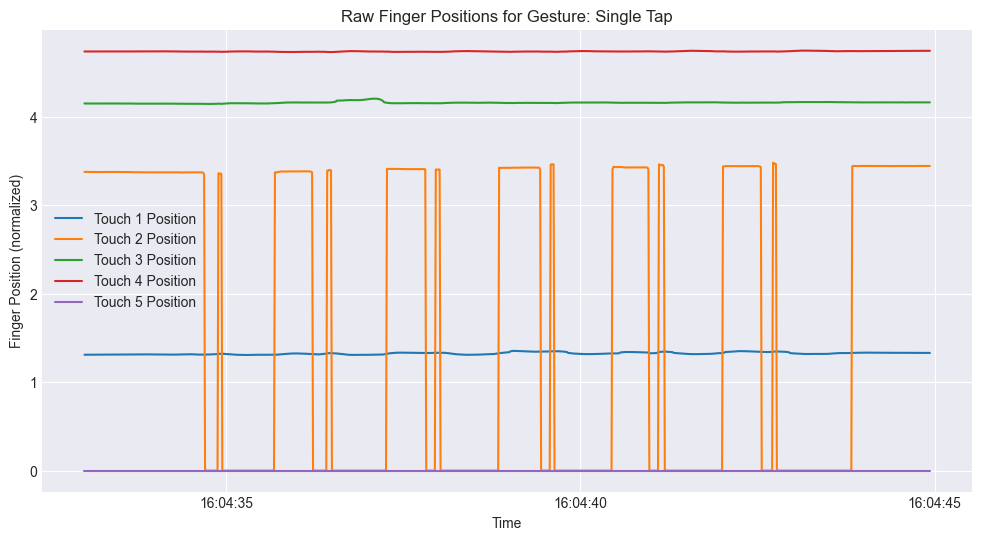

In [25]:
# Draw a graph of the raw finger position data for the same sample
raw_sample = df_clean[df_clean["session_task_id"] == meta_data_df.iloc[indices[0]]["session_task_id"]]
plt.figure(figsize=(12, 6))
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    plt.plot(raw_sample['estimated_timestamp'], raw_sample[pos_col], label=f'Touch {i+1} Position')
plt.xlabel('Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Raw Finger Positions for Gesture: {gesture_name}')
plt.legend()
plt.show()

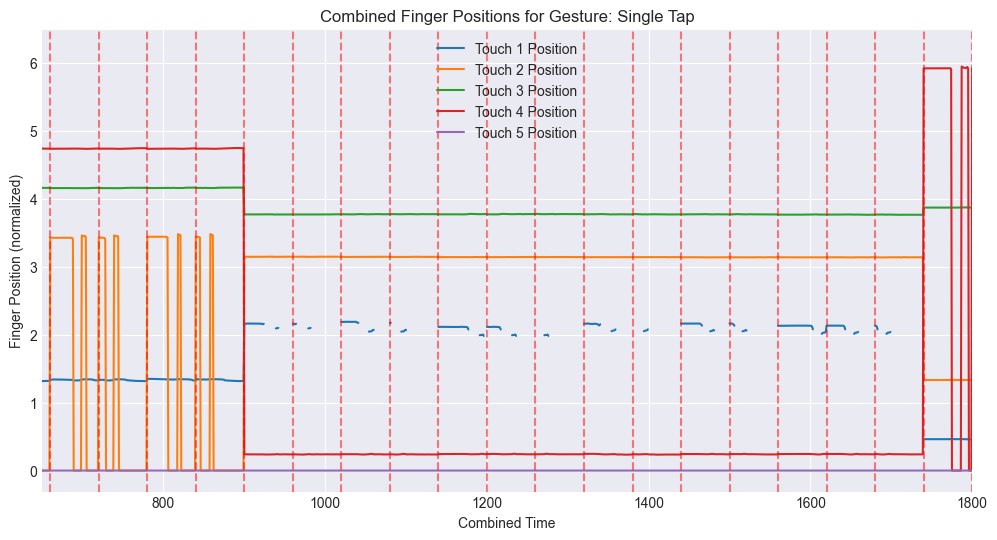

In [26]:
# Draw a graph of the finger positions for all windows that was classified as the gesture, as if they where performed right after one another, with vertical colored lines indicating the window boundaries
plt.figure(figsize=(12, 6))
for i in range(5):
    pos_col = f'touch_{i+1}_position'
    combined_positions = []
    for idx in indices:
        combined_positions.extend(X_windows[idx, :, 2 + i * 3])  # touch_X_position index in SENSOR_COLUMNS
    plt.plot(combined_positions, label=f'Touch {i+1} Position')
plt.xlabel('Combined Time')
plt.ylabel('Finger Position (normalized)')
plt.title(f'Combined Finger Positions for Gesture: {gesture_name}')
# Draw vertical lines for window boundaries
for w in range(1, len(indices)):
    plt.axvline(x=w * WINDOW_SIZE_SAMPLES, color='red', linestyle='--', alpha=0.5)
plt.xlim(650, 1800)
plt.legend()
plt.show()

In [27]:
participant_ids = meta_data_df['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 2]
val_pids = participant_ids[amount_of_participants - 2:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

print(f"Amount of participants: {amount_of_participants} (Train: {len(train_pids)}, Val: {len(val_pids)}, Test: {len(test_pids)})")

Amount of participants: 8 (Train: 6, Val: 1, Test: 1)


In [28]:
# Split sliding windows
train_mask_win = meta_data_df['participant_id'].isin(train_pids)
X_train_win = X_win[train_mask_win]
y_train_win = y_windows_encoded[train_mask_win]

val_mask_win = meta_data_df['participant_id'].isin(val_pids)
X_val_win = X_win[val_mask_win]
y_val_win = y_windows_encoded[val_mask_win]

test_mask_win = meta_data_df['participant_id'].isin(test_pids)
X_test_win = X_win[test_mask_win]
y_test_win = y_windows_encoded[test_mask_win]

In [29]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train_win == label_int)
    val_count = np.sum(y_val_win == label_int)
    test_count = np.sum(y_test_win == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: Double Tap | Train: 257 | Val: 40 | Test: 47
Label: No Gesture | Train: 6036 | Val: 333 | Test: 1062
Label: Pinch Swipe | Train: 440 | Val: 48 | Test: 92
Label: Single Swipe | Train: 291 | Val: 37 | Test: 55
Label: Single Tap | Train: 217 | Val: 31 | Test: 35
Label: Spread Swipe | Train: 304 | Val: 53 | Test: 68
Label: Tap and Hold | Train: 616 | Val: 83 | Test: 108
Label: Two-Finger Double Tap | Train: 281 | Val: 40 | Test: 44
Label: Two-Finger Opposite Double Tap | Train: 174 | Val: 22 | Test: 28
Label: Two-Finger Opposite Tap | Train: 125 | Val: 17 | Test: 19
Label: Two-Finger Tap | Train: 246 | Val: 38 | Test: 33


In [30]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Sliding Window Split:")
print(f"  X_train_win: {X_train_win.shape}, y_train_win: {y_train_win.shape}")
print(f"  X_val_win:   {X_val_win.shape},   y_val_win:   {y_val_win.shape}")
print(f"  X_test_win:  {X_test_win.shape},  y_test_win:  {y_test_win.shape}")

Sliding Window Split:
  X_train_win: (8987, 371), y_train_win: (8987,)
  X_val_win:   (742, 371),   y_val_win:   (742,)
  X_test_win:  (1591, 371),  y_test_win:  (1591,)


In [31]:
# Scale both datasets
scaler = StandardScaler()
X_train_win = scaler.fit_transform(X_train_win)
X_val_win = scaler.transform(X_val_win)
X_test_win = scaler.transform(X_test_win)

In [32]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform, loguniform

MODEL_CONFIGS = [

    # =====================================================
    # Random Forest
    # =====================================================
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(200, 1000),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },

    # =====================================================
    # Gradient Boosting
    # =====================================================
    {
        "name": "GradientBoosting",
        "pipeline": Pipeline([
            ("clf", GradientBoostingClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":   randint(100, 600),
            "clf__learning_rate":  loguniform(1e-2, 2e-1),
            "clf__max_depth":      randint(2, 6),
            "clf__subsample":      uniform(0.6, 0.4),   # 0.6–1.0
        },
    },

    # =====================================================
    # Logistic Regression
    # =====================================================
    {
        "name": "LogisticRegression",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                multi_class="multinomial",
                n_jobs=-1,
                solver="lbfgs"
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
            ],
        },
    },

    # =====================================================
    # k-Nearest Neighbors
    # =====================================================
    # {
    #     "name": "KNN",
    #     "pipeline": Pipeline([
    #         ("scaler", StandardScaler()),
    #         ("clf", KNeighborsClassifier())
    #     ]),
    #     "param_grid": {
    #         "clf__n_neighbors": randint(3, 40),
    #         "clf__weights":     ["uniform", "distance"],
    #         "clf__p":           [1, 2],
    #     },
    # },

    # =====================================================
    # Extra Trees
    # =====================================================
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(300, 1200),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },

    # =====================================================
    # Linear SVM
    # =====================================================
    {
        "name": "LinearSVC",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                max_iter=5000,
                dual=False
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },

    # =====================================================
    # Radius Neighbors
    # =====================================================
    # {
    #     "name": "RadiusNeighbors",
    #     "pipeline": Pipeline([
    #         ("scaler", StandardScaler()),
    #         ("clf", RadiusNeighborsClassifier(
    #             outlier_label="most_frequent"
    #         ))
    #     ]),
    #     "param_grid": {
    #         "clf__radius":  loguniform(1e-1, 5.0),
    #         "clf__weights": ["uniform", "distance"],
    #         "clf__p":       [1, 2],
    #     },
    # },
    {
        "name": "AdaBoost",
        "pipeline": Pipeline([
            ("clf", AdaBoostClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(100, 600),
            "clf__learning_rate": loguniform(1e-2, 1.0),
        },
    }
]

In [34]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
)
import numpy as np
import pandas as pd

# SCORING = make_scorer(recall_score, pos_label=yes_label_int, average="macro")
SCORERS = {
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score),
}

OPTIMIZE_METRIC = "f1"

gkf = GroupKFold(n_splits=amount_of_participants - 1)
groups_train_win = 

best_model = None
best_model_name = None
best_score = -np.inf

rows = []
for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]

    print(f"\n=== Tuning {name} ===")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_grid"],
        n_iter=40,
        cv=gkf,
        scoring=SCORERS,
        refit=OPTIMIZE_METRIC,
        return_train_score=True,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search.fit(X_train_win, y_train_win, groups=groups_train_win)

    idx = search.best_index_
    cv = search.cv_results_

    # -----------------------------
    # Track best overall model
    # -----------------------------
    if cv[f"mean_test_{OPTIMIZE_METRIC}"][idx] > best_score:
        best_score = cv[f"mean_test_{OPTIMIZE_METRIC}"][idx]
        best_model = search.best_estimator_
        best_model_name = name

    # -----------------------------
    # Store CV stats
    # -----------------------------
    row = {
        "model": name,
        "cv_recall": cv["mean_test_recall"][idx],
        "cv_recall_std": cv["std_test_recall"][idx],
        "cv_precision": cv["mean_test_precision"][idx],
        "cv_precision_std": cv["std_test_precision"][idx],
        "cv_f1": cv["mean_test_f1"][idx],
        "cv_f1_std": cv["std_test_f1"][idx],
        "train_recall_cv": cv["mean_train_recall"][idx],
        "train_precision_cv": cv["mean_train_precision"][idx],
        "train_f1_cv": cv["mean_train_f1"][idx],
        'best_model': search.best_estimator_,
        **search.best_params_,
    }

    rows.append(row)

# Print the best model stats
print(f"\n=== Best Model: {best_model_name} ===")
print(f"Best CV {OPTIMIZE_METRIC}: {best_score:.4f}")

TypeError: list indices must be integers or slices, not Series

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test_win)

# print("Test classification report:\n",
#       classification_report(y_test_win, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_win, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [ ]:
# Print which features are the most influencial for the best model if possible
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    print("\nTop 50 Feature Importances:")
    for fname, importance in feature_importance_pairs[:50]:
        print(f"{fname}: {importance:.4f}")